# 집에서 언제 출발해야 따릉이를 탈 수 있을까?

데이터마이닝 기말 프로젝트 Notebook


In [1]:
import sys
import os
from datetime import datetime
from pathlib import Path
import folium
import joblib
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from dotenv import load_dotenv
ROOT = Path.cwd()
if not (ROOT / 'src').exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))
load_dotenv(ROOT / '.env')
import importlib
import src.kakao_map as kakao_map
import src.predict as predict_module
importlib.reload(kakao_map)
importlib.reload(predict_module)
from src.config import (
    DEMO_ADDRESS, DEMO_AVAILABLE_MINUTES, DEMO_ORIGIN_LAT, DEMO_ORIGIN_LNG,
    DEMO_REF_TIME, KAKAO_REST_PLACEHOLDER, ML_MAX_ROWS,
)
from src.clustering import cluster_stations, save_stations
from src.etl import run_etl
from src.kakao_map import has_rest_api_key
from src.ml_models import train_models
from src.paths import MODELS, PROCESSED
from src.predict import predict_origin_rental, print_origin_prediction_summary
from src.stations import load_stations
REBUILD = False
FORCE_COORD_MODE = False
USE_ADDRESS = (not FORCE_COORD_MODE) and has_rest_api_key()
sns.set_theme(style='whitegrid')
MODELS.mkdir(exist_ok=True)
print('입력 모드:', '주소 (Kakao REST API)' if USE_ADDRESS else '좌표 (Demo)')


입력 모드: 주소 (Kakao REST API)


## 1. Data Load and ETL


In [2]:
stations = load_stations()
if REBUILD or not (PROCESSED / 'stations.csv').exists():
    stations = cluster_stations(stations)
    save_stations(stations)
else:
    stations = pd.read_csv(PROCESSED / 'stations.csv', encoding='utf-8')
data = run_etl(stations, rebuild=REBUILD)
zone_hour = data['zone_hour']
ml_train = data['ml_train']
sample_path = PROCESSED / 'ml_train_sample.csv'
if sample_path.exists():
    ml_train = pd.read_csv(sample_path, encoding='utf-8')
elif len(ml_train) > ML_MAX_ROWS:
    ml_train = ml_train.sample(ML_MAX_ROWS, random_state=42)
print(len(stations), 'stations |', len(zone_hour), 'zone-hour rows')
ml_train.head()


2799 stations | 2670911 zone-hour rows


,date,hour,cluster_id,bike_count_mean,bike_count_max,availability_rate,month,dow,is_weekend,season
0,2024-01-01,2,940,31.0,31,1.0,1,0,0,winter
1,2024-01-02,13,1172,1.0,1,1.0,1,1,0,winter
2,2024-01-10,22,1565,4.0,4,1.0,1,2,0,winter
3,2024-01-02,1,368,74.0,109,1.0,1,1,0,winter
4,2024-01-12,18,303,11.0,11,1.0,1,4,0,winter


## 2. EDA


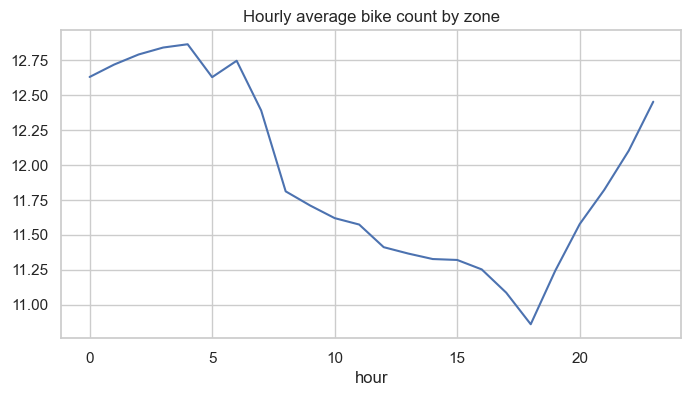

Zero rate: 0.06479549487047678


In [3]:
fig, ax = plt.subplots(figsize=(8,4))
zone_hour.groupby('hour')['bike_count_mean'].mean().plot(ax=ax)
ax.set_title('Hourly average bike count by zone')
plt.show()
print('Zero rate:', (zone_hour['bike_count_mean']==0).mean())


## 3. Clustering map


In [4]:
m = folium.Map([stations['lat'].mean(), stations['lng'].mean()], zoom_start=12)
for _, r in stations.sample(min(300,len(stations)), random_state=42).iterrows():
    folium.CircleMarker([r['lat'], r['lng']], radius=3, color='blue', fill=True).add_to(m)
m


## 4. ML models


In [5]:
results = train_models(ml_train, max_rows=ML_MAX_ROWS)
results['comparison']


,model,MAE,RMSE,R2
0,Linear Regression,7.317594,9.785607,0.008787
1,Random Forest,5.167198,7.384001,0.435616
2,RF Tuned,5.015011,7.119167,0.475374


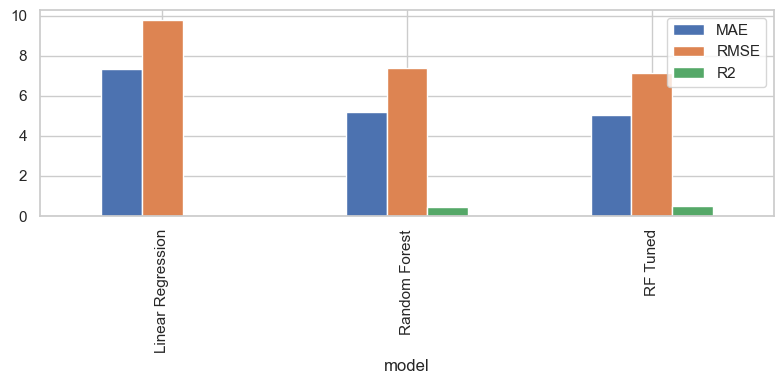

Best params: {'model__max_depth': None, 'model__min_samples_leaf': 3, 'model__n_estimators': 150}


['C:\\Users\\skuy3\\OneDrive\\바탕 화면\\데이터마이닝 기말 프로젝트\\models\\rf_tuned.joblib']

In [6]:
results['comparison'].set_index('model').plot(kind='bar', figsize=(8,4))
plt.tight_layout(); plt.show()
print('Best params:', results['best_params'])
joblib.dump(results['linear'], MODELS/'linear_regression.joblib')
joblib.dump(results['rf'], MODELS/'random_forest.joblib')
joblib.dump(results['tuned'], MODELS/'rf_tuned.joblib')


## 5. Prediction demo

**출발 주소** + **할당 가능 소요시간(분)**


In [7]:
REF_TIME = pd.Timestamp(DEMO_REF_TIME).to_pydatetime()
result = None
if USE_ADDRESS:
    try:
        result = predict_origin_rental(
            stations, results['models_dict'],
            DEMO_ADDRESS, DEMO_AVAILABLE_MINUTES,
            reference_time=REF_TIME,
        )
    except RuntimeError as exc:
        print(exc)
        print('→ 좌표 Demo로 대체 실행합니다.')
if result is None:
    result = predict_origin_rental(
        stations, results['models_dict'],
        None, DEMO_AVAILABLE_MINUTES,
        origin_lat=DEMO_ORIGIN_LAT, origin_lng=DEMO_ORIGIN_LNG,
        reference_time=REF_TIME,
    )
print_origin_prediction_summary(result)


ValueError: Address not found: 서울특별시 마포구 월드억로 72

## 6. Interactive input

**출발 주소**와 **할당 가능 소요시간(분)** 입력 후 **예측 실행**


In [ ]:
import ipywidgets as widgets
from IPython.display import display, clear_output

origin_addr = widgets.Text(
    value=DEMO_ADDRESS,
    description='출발 주소',
    layout=widgets.Layout(width='95%'),
)
available_min = widgets.IntSlider(
    value=DEMO_AVAILABLE_MINUTES, min=5, max=120, step=5,
    description='할당 시간(분)',
)
run_btn = widgets.Button(description='예측 실행', button_style='primary')
out = widgets.Output()

def _run_prediction(_=None):
    with out:
        clear_output(wait=True)
        try:
            ref = datetime.now()
            res = None
            if USE_ADDRESS:
                try:
                    res = predict_origin_rental(
                        stations, results['models_dict'],
                        origin_addr.value.strip(), available_min.value,
                        reference_time=ref,
                    )
                except RuntimeError as exc:
                    print(exc)
                    print('→ 좌표 Demo로 대체 실행합니다.')
            if res is None:
                res = predict_origin_rental(
                    stations, results['models_dict'],
                    None, available_min.value,
                    reference_time=ref,
                    origin_lat=DEMO_ORIGIN_LAT, origin_lng=DEMO_ORIGIN_LNG,
                )
            print_origin_prediction_summary(res)
            m = folium.Map([res['origin_lat'], res['origin_lng']], zoom_start=14)
            folium.Marker(
                [res['origin_lat'], res['origin_lng']],
                popup=f"출발 (구역 {res['origin_cluster']})",
                icon=folium.Icon(color='green', icon='home'),
            ).add_to(m)
            folium.CircleMarker(
                [res['nearest_station_lat'], res['nearest_station_lng']],
                radius=8, color='blue', fill=True,
                popup=f"대여소: {res['nearest_station']}",
            ).add_to(m)
            display(m)
        except Exception as exc:
            print(f'오류: {exc}')

run_btn.on_click(_run_prediction)
display(widgets.VBox([origin_addr, available_min, run_btn, out]))


## 7. Summary

UAT 경험 요약: `docs/uat-experience.md`
